# Exercise 5

## Exercise 5.1

In [38]:
import numpy as np
import matplotlib.pyplot as plt

In [39]:
def update_assignments(data, centroids):
    assignments = np.zeros(data.shape[0], dtype=int)

    for i in range(data.shape[0]):
        distances = np.linalg.norm(data[i] - centroids, axis=1)
        assignments[i] = np.argmin(distances)

    return assignments

def update_centroids(data, old_centroids, assignments):
    new_centroids = np.zeros(old_centroids.shape)

    for i in range(old_centroids.shape[0]):
        assigned_data = data[assignments == i]
        if assigned_data.shape[0] > 0:
            new_centroids[i] = np.mean(assigned_data, axis=0)
        else:
            new_centroids[i] = old_centroids[i]

    return new_centroids

In [40]:
data = np.loadtxt('blobs.dat').T

# choose three random data points and assign them as the initial centroids
initial_indexes = np.random.choice(data.shape[0], size=3, replace=False)
centroids = data[initial_indexes]

# Run 5 iterations
for i in range(5):
    assignments = update_assignments(data, centroids)
    centroids = update_centroids(data, centroids, assignments)
    print(f"Centroids in iteration {i+1}:\n{centroids}\n")



Centroids in iteration 1:
[[-6.01421998  7.35594593]
 [-4.65082655 -1.65023272]
 [-5.52079501  0.30994486]]

Centroids in iteration 2:
[[-5.91079309  7.30602694]
 [-4.7714005  -1.66997941]
 [-5.88992236 -0.15305941]]

Centroids in iteration 3:
[[-5.91079309  7.30602694]
 [-4.7714005  -1.66997941]
 [-5.88992236 -0.15305941]]

Centroids in iteration 4:
[[-5.91079309  7.30602694]
 [-4.7714005  -1.66997941]
 [-5.88992236 -0.15305941]]

Centroids in iteration 5:
[[-5.91079309  7.30602694]
 [-4.7714005  -1.66997941]
 [-5.88992236 -0.15305941]]



## Exercise 5.2

In [41]:
def compute_wcss(data, centroids, assignments):
    wcss = 0
    for i in range(data.shape[0]):
        centroid = centroids[assignments[i]]
        wcss += np.sum((data[i] - centroid)**2)
    return wcss


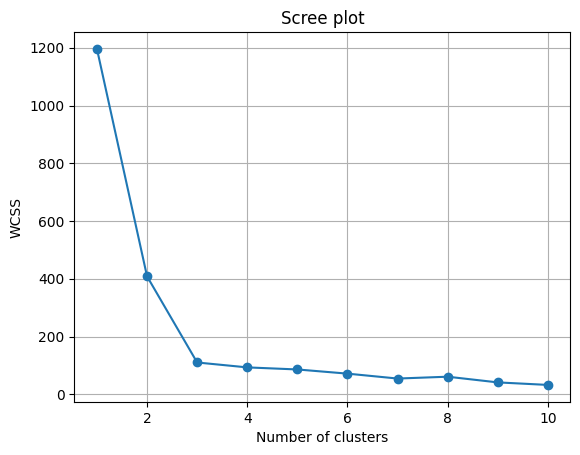

In [42]:
data = np.loadtxt('blobs.dat').T

K_values = range(1, 11)
wcss_values = []

for K in K_values:
    initial_index = np.random.choice(data.shape[0], size=K, replace=False)
    centroids = data[initial_index]

    # run 10 iterations
    for _ in range(10):
        assignments = update_assignments(data, centroids)
        centroids = update_centroids(data, centroids, assignments)

    wcss = compute_wcss(data, centroids, assignments)
    wcss_values.append(wcss)

plt.plot(K_values, wcss_values, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.title("Scree plot")
plt.grid(True)
plt.show()


### Is there a clear indication of the correct value for K?

Yes. The scree plot shows a steep decrease in WCSS from K = 1 to K = 3, after which the curve begins to flatten. This indicates that adding more clusters beyond K = 3 yields only marginal improvement. This suggests that K = 3 is a reasonable choice for the number of clusters in this dataset.